In [ ]:
#add libraries
import pandas as pd #for data manipulation and analysis(para manipulación y análisis de datos)
import numpy as np # for numeriacal operations(para operaciones numéricas)
import matplotlib.pyplot as plt #for data vizualization using charts(para visualización de datos mediante gráficos)
import seaborn as sns #for stadistical data vizualization(para la visualización de datos estadísticos)

# Carga de datos

In [ ]:
academico = "dataset_academico.csv"
psicosocial = "dataset_psicosocial.csv"
df_academico = pd.read_csv(academico)
df_psicosocial = pd.read_csv(psicosocial)


In [ ]:
df_academico.head()

,id_estudiante,edad,grado,promedio_matematica,promedio_comunicacion,promedio_ciencias,promedio_general,num_cursos_desaprobados,porcentaje_asistencia,num_tardanzas,num_inasistencias_injustificadas,tendencia_notas,participacion_clase,entrega_tareas,repitio_grado,horas_estudio_semanal,target
0,3169,16.0,5,10.85,14.06,12.30,13.37,0,77.5,6,1,Empeorando,Media,64.4,1,3.9,Continua_estudiando
1,1163,15.0,3,18.63,14.59,16.66,17.37,0,100.0,1,0,Mejorando,Media,100.0,0,12.8,Continua_estudiando
2,2517,13.0,2,20.00,16.54,14.42,16.74,0,98.5,2,2,Estable,Alta,77.5,0,13.8,Continua_estudiando
3,2318,13.0,1,16.91,19.40,19.70,18.24,1,95.4,1,5,NaN,Alta,73.1,1,16.1,Continua_estudiando
4,1686,17.0,5,17.83,13.27,14.91,15.59,0,87.4,2,2,Estable,Media,92.9,0,12.9,Continua_estudiando


In [ ]:
df_psicosocial.head()

,id_estudiante,genero,estructura_familiar,num_hermanos,nivel_socioeconomico,nivel_educativo_padres,trabaja_estudiante,horas_trabajo_semanal,acceso_internet_hogar,distancia_colegio_km,nivel_autoestima,nivel_ansiedad,nivel_motivacion_escolar,apoyo_familiar_percibido,eventos_estresantes_recientes,relacion_con_companeros,horas_sueño_diarias,consumo_sustancias,participa_actividades_extracurriculares,atencion_psicologica_previa
0,2467,Femenino,Un solo padre,3,Medio,Superior,0,NaN,1,6.61,4.0,3,4,3,0,Regular,7.4,0,0,0
1,3555,Masculino,Ambos padres,2,Medio,Superior,0,NaN,0,0.87,NaN,3,4,2,0,Regular,8.3,0,0,0
2,3064,Masculino,Ambos padres,0,Alto,Secundaria,0,NaN,1,0.28,3.0,3,1,5,0,Buena,5.6,0,1,0
3,1189,Femenino,Otros familiares,3,Medio-bajo,Secundaria,1,16.2,1,4.02,3.0,3,3,3,0,Regular,6.9,0,0,0
4,3779,Masculino,Ambos padres,0,Medio,Superior,0,NaN,1,3.51,5.0,3,4,4,0,Buena,7.5,1,0,0


In [ ]:
#aplicamos la fucion por ID
df_unido = pd.merge(
    df_academico,
    df_psicosocial,
    on="id_estudiante",
    how="inner"
)

# Show merged dataset shape
print("Merged dataset shape:", df_unido.shape)


Merged dataset shape: (3000, 36)


In [ ]:
display(df_unido.head())

,id_estudiante,edad,grado,promedio_matematica,promedio_comunicacion,promedio_ciencias,promedio_general,num_cursos_desaprobados,porcentaje_asistencia,num_tardanzas,...,nivel_autoestima,nivel_ansiedad,nivel_motivacion_escolar,apoyo_familiar_percibido,eventos_estresantes_recientes,relacion_con_companeros,horas_sueño_diarias,consumo_sustancias,participa_actividades_extracurriculares,atencion_psicologica_previa
0,3169,16.0,5,10.85,14.06,12.30,13.37,0,77.5,6,...,5.0,1,4,4,0,Regular,7.2,0,1,1
1,1163,15.0,3,18.63,14.59,16.66,17.37,0,100.0,1,...,3.0,2,5,3,0,Regular,7.9,0,0,0
2,2517,13.0,2,20.00,16.54,14.42,16.74,0,98.5,2,...,3.0,2,5,4,0,Regular,6.7,0,0,0
3,2318,13.0,1,16.91,19.40,19.70,18.24,1,95.4,1,...,5.0,2,3,3,0,Buena,5.2,0,1,0
4,1686,17.0,5,17.83,13.27,14.91,15.59,0,87.4,2,...,4.0,2,3,4,0,Buena,6.8,0,1,0


# Eda

trabajamos con las base de datos unidos si hay valores nulos

In [ ]:
df_unido.isnull().sum()

,0
id_estudiante,0
edad,0
grado,0
promedio_matematica,0
promedio_comunicacion,0
promedio_ciencias,90
promedio_general,0
num_cursos_desaprobados,0
porcentaje_asistencia,60
num_tardanzas,0


In [ ]:
# ==========================================
# FILTER COLUMNS WITH MISSING VALUES BY TYPE
# ==========================================

# Identify numeric columns with missing values
numeric_null_cols = df_unido.select_dtypes(include=["int64", "float64"]).columns
numeric_null_cols = df_unido[numeric_null_cols].columns[df_unido[numeric_null_cols].isnull().sum() > 0]

# Identify categorical/text columns with missing values
categorical_null_cols = df_unido.select_dtypes(include=["object", "category"]).columns
categorical_null_cols = df_unido[categorical_null_cols].columns[df_unido[categorical_null_cols].isnull().sum() > 0]

print("Numeric columns with missing values:")
print(list(numeric_null_cols))

print("\nCategorical columns with missing values:")
print(list(categorical_null_cols))

Numeric columns with missing values:
['promedio_ciencias', 'porcentaje_asistencia', 'entrega_tareas', 'horas_estudio_semanal', 'horas_trabajo_semanal', 'distancia_colegio_km', 'nivel_autoestima']

Categorical columns with missing values:
['tendencia_notas', 'nivel_socioeconomico', 'nivel_educativo_padres', 'relacion_con_companeros']


In [ ]:
df_unido.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 36 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   id_estudiante                            3000 non-null   int64  
 1   edad                                     3000 non-null   float64
 2   grado                                    3000 non-null   int64  
 3   promedio_matematica                      3000 non-null   float64
 4   promedio_comunicacion                    3000 non-null   float64
 5   promedio_ciencias                        2910 non-null   float64
 6   promedio_general                         3000 non-null   float64
 7   num_cursos_desaprobados                  3000 non-null   int64  
 8   porcentaje_asistencia                    2940 non-null   float64
 9   num_tardanzas                            3000 non-null   int64  
 10  num_inasistencias_injustificadas         3000 no

In [ ]:
for columna in df_unido.columns:
    print(f"\n===== {columna} =====")
    print(df_unido[columna].unique())


===== id_estudiante =====
[3169 1163 2517 ... 1306 3844 2860]

===== edad =====
[16. 15. 13. 17. 12. 14.  6. 30. 25.]

===== grado =====
[5 3 2 1 4]

===== promedio_matematica =====
[10.85 18.63 20.   ...  9.24 17.02  9.42]

===== promedio_comunicacion =====
[14.06 14.59 16.54 ...  6.61 19.23  5.61]

===== promedio_ciencias =====
[12.3  16.66 14.42 ...  3.43 17.25  3.  ]

===== promedio_general =====
[13.37 17.37 16.74 ...  4.08 15.6   7.  ]

===== num_cursos_desaprobados =====
[0 1 2 3 4 6 5 8 7 9]

===== porcentaje_asistencia =====
[ 77.5 100.   98.5  95.4  87.4  59.2  55.4  88.4  90.8  88.3  84.7  70.4
  85.4  71.8  93.6  75.7  69.9  62.4  80.5  49.4  84.5  74.   85.9  90.1
  92.5  79.8  77.   70.   76.4  91.1  81.9  75.6  70.3  85.2  67.   75.1
  89.   72.8  93.1  78.3  77.4  71.2  83.3  63.5  75.   72.1  73.5  55.1
  75.2  89.2  78.2  85.6  93.5  58.4   nan  90.7  78.8  72.6  55.8  87.1
  69.   81.5  77.7  80.8  63.6  86.5  85.7  62.3  56.8  63.9 112.7  81.7
  56.6  58.2  78.7  6

In [ ]:
# Detectar outliers

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Seleccionamos el numero de columnas
numeric_cols = df_unido.select_dtypes(include=np.number).columns

outlier_summary = []

for col in numeric_cols:

    Q1 = df_unido[col].quantile(0.25)
    Q3 = df_unido[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    outliers = df_unido[(df_unido[col] < lower_limit) |
                         (df_unido[col] > upper_limit)]

    outlier_summary.append({
        "Column": col,
        "Lower Limit": lower_limit,
        "Upper Limit": upper_limit,
        "Outliers Count": outliers.shape[0],
        "Outliers Percentage": round((outliers.shape[0] / len(df_unido)) * 100, 2)
    })

outlier_summary_df = pd.DataFrame(outlier_summary)

outlier_summary_df.sort_values(by="Outliers Count", ascending=False)

,Column,Lower Limit,Upper Limit,Outliers Count,Outliers Percentage
27,atencion_psicologica_previa,0.00000,0.00000,710,23.67
12,repitio_grado,0.00000,0.00000,500,16.67
25,consumo_sustancias,0.00000,0.00000,260,8.67
14,num_hermanos,-0.50000,3.50000,249,8.30
18,distancia_colegio_km,-3.81500,8.30500,137,4.57
10,num_inasistencias_injustificadas,-5.50000,14.50000,26,0.87
24,horas_sueño_diarias,3.25000,10.05000,21,0.70
7,num_cursos_desaprobados,-4.50000,7.50000,21,0.70
9,num_tardanzas,-5.50000,14.50000,14,0.47
16,horas_trabajo_semanal,7.20000,34.40000,9,0.30


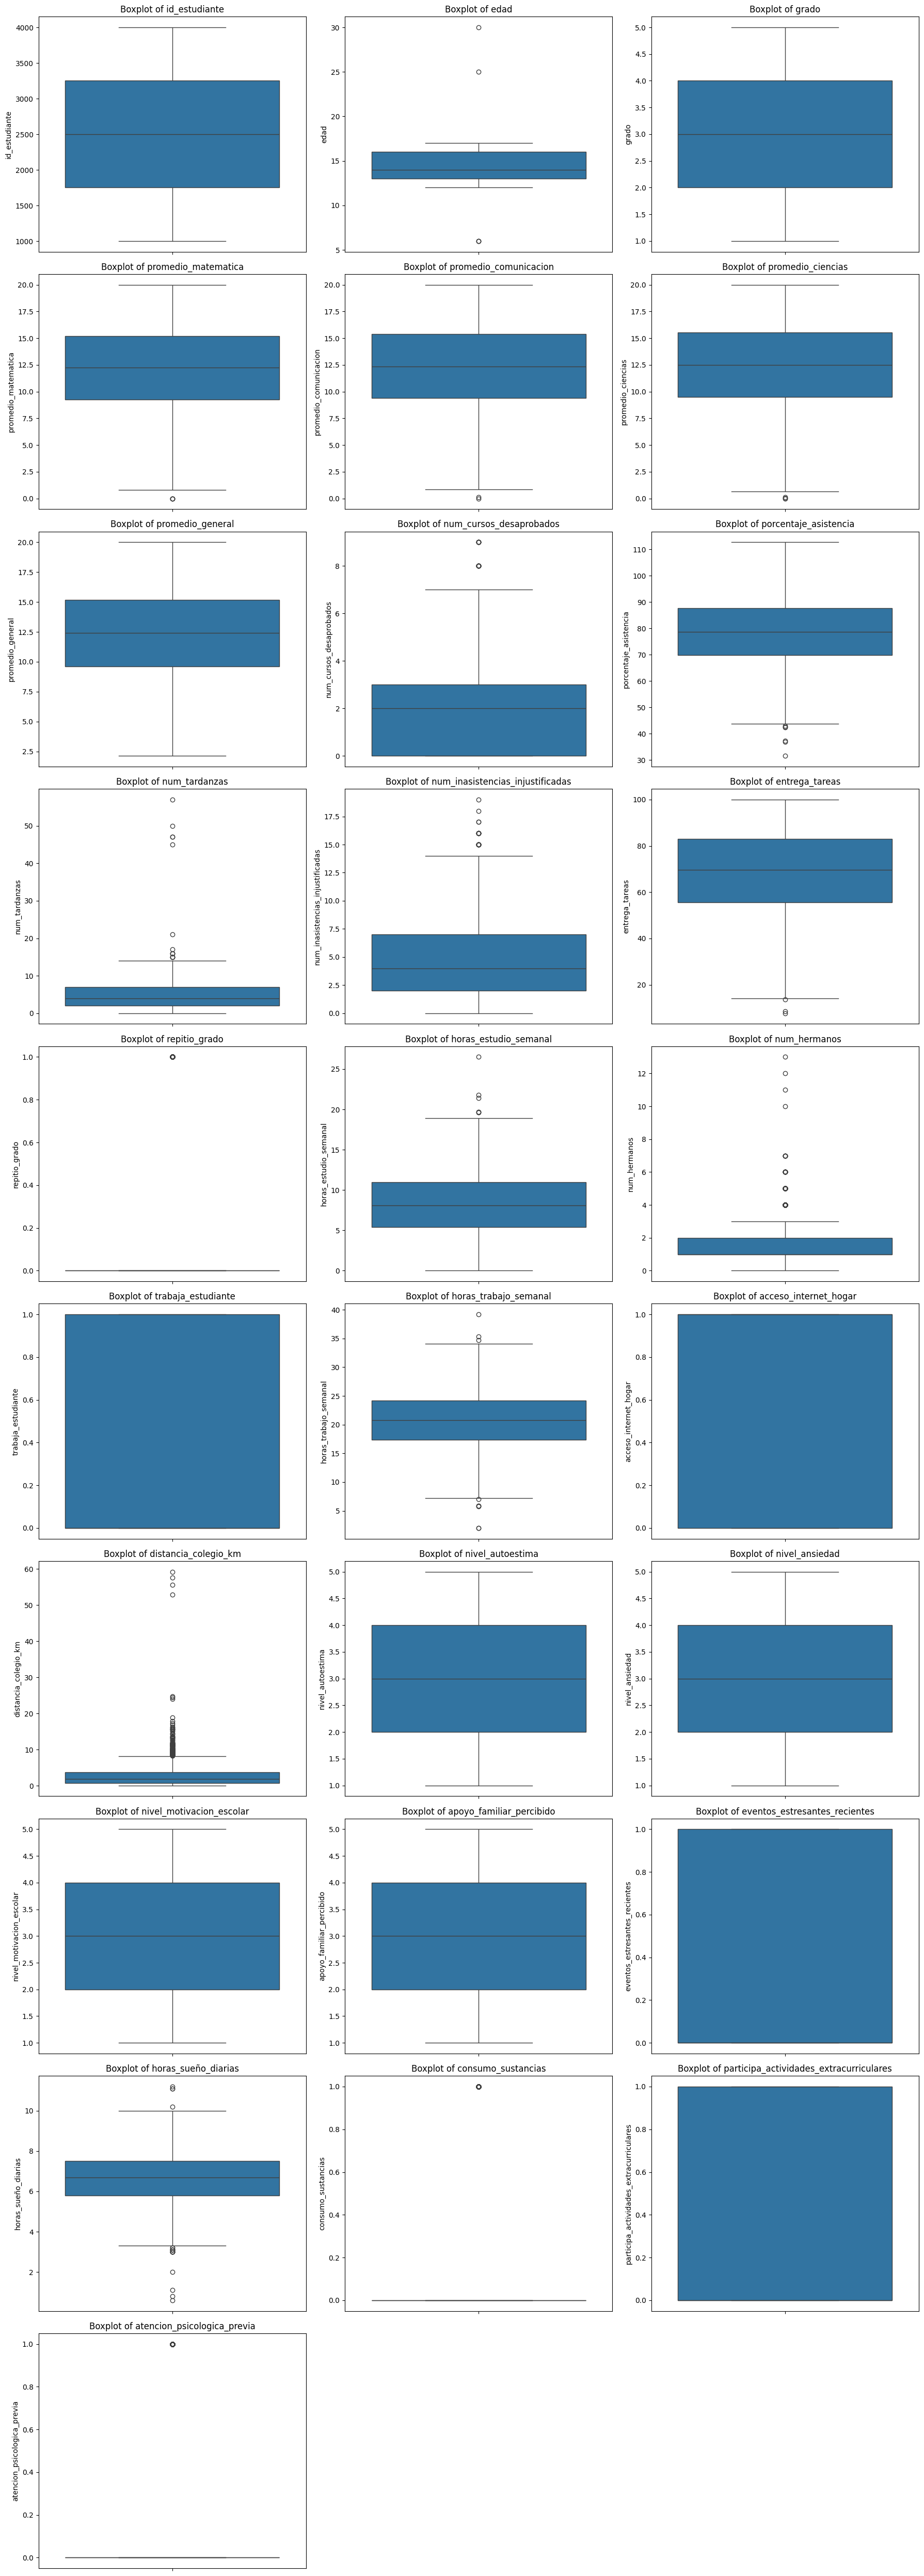

In [ ]:
# Visualize outliers en boxplots de cada columna

numeric_cols = df_unido.select_dtypes(include=np.number).columns

plt.figure(figsize=(18, 5 * ((len(numeric_cols) // 3) + 1)))

for i, col in enumerate(numeric_cols):

    plt.subplot((len(numeric_cols) // 3) + 1, 3, i + 1)
    sns.boxplot(y=df_unido[col])
    plt.title(f"Boxplot of {col}")

plt.tight_layout()
plt.show()

In [ ]:
# para ver los tipos de datos
df_examen.dtypes

In [ ]:
# valanceo de target
target = "Target"

df_examen[target].value_counts()

# Preprocesamiento

In [ ]:
ge dumies

manejando los valores nulos

In [ ]:
#imputamos a los valores nulos con la mediana

numeric_null_cols = [
    "promedio_ciencias",
    "porcentaje_asistencia",
    "entrega_tareas",
    "horas_estudio_semanal",
    "horas_trabajo_semanal",
    "distancia_colegio_km"

]


for col in numeric_null_cols:
    median_value = df_unido[col].median()
    df_unido[col] = df_unido[col].fillna(median_value)
    print(f"{col}: missing values replaced with median = {median_value}")


print("\nMissing values after numeric imputation:")
display(df_unido[numeric_null_cols].isnull().sum())

promedio_ciencias: missing values replaced with median = 12.49
porcentaje_asistencia: missing values replaced with median = 78.7
entrega_tareas: missing values replaced with median = 69.6
horas_estudio_semanal: missing values replaced with median = 8.1
horas_trabajo_semanal: missing values replaced with median = 20.8
distancia_colegio_km: missing values replaced with median = 1.86

Missing values after numeric imputation:


,0
promedio_ciencias,0
porcentaje_asistencia,0
entrega_tareas,0
horas_estudio_semanal,0
horas_trabajo_semanal,0
distancia_colegio_km,0


In [ ]:
median_autoestima = df_unido["nivel_autoestima"].median()

df_unido["nivel_autoestima"] = df_unido["nivel_autoestima"].fillna(median_autoestima)

print("Median used for nivel_autoestima:", median_autoestima)
print("Missing values:", df_unido["nivel_autoestima"].isnull().sum())

Median used for nivel_autoestima: 3.0
Missing values: 0


In [ ]:
df_unido["nivel_autoestima"].isnull().sum()

np.int64(0)

,0
id_estudiante,0
edad,0
grado,0
promedio_matematica,0
promedio_comunicacion,0
promedio_ciencias,0
promedio_general,0
num_cursos_desaprobados,0
porcentaje_asistencia,0
num_tardanzas,0


In [ ]:

# IMPUTE categorias por valores de la moda


categorical_null_cols = [
    "tendencia_notas",
    "nivel_socioeconomico",
    "nivel_educativo_padres",
    "relacion_con_companeros"
]

for col in categorical_null_cols:
    mode_value = df_unido[col].mode()[0]
    df_unido[col] = df_unido[col].fillna(mode_value)
    print(f"{col}: missing values replaced with mode = {mode_value}")

# Verify missing values
print("\nMissing values after categorical imputation:")
display(df_unido[categorical_null_cols].isnull().sum())

tendencia_notas: missing values replaced with mode = Mejorando
nivel_socioeconomico: missing values replaced with mode = Medio
nivel_educativo_padres: missing values replaced with mode = Secundaria
relacion_con_companeros: missing values replaced with mode = Regular

Missing values after categorical imputation:


,0
tendencia_notas,0
nivel_socioeconomico,0
nivel_educativo_padres,0
relacion_con_companeros,0


asignando numeros para los datos ordinales

In [26]:
# Removed: Redundant ordinal encoding, already handled in cell m4ypOmX3ZSQY.

In [27]:
# Removed: Redundant ordinal encoding, already handled in cell m4ypOmX3ZSQY.

In [28]:
df_unido.head()

,id_estudiante,edad,grado,promedio_matematica,promedio_comunicacion,promedio_ciencias,promedio_general,num_cursos_desaprobados,porcentaje_asistencia,num_tardanzas,...,nivel_autoestima,nivel_ansiedad,nivel_motivacion_escolar,apoyo_familiar_percibido,eventos_estresantes_recientes,relacion_con_companeros,horas_sueño_diarias,consumo_sustancias,participa_actividades_extracurriculares,atencion_psicologica_previa
0,3169,16.0,5,10.85,14.06,12.30,13.37,0,77.5,6,...,5.0,1,4,4,0,1,7.2,0,1,1
1,1163,15.0,3,18.63,14.59,16.66,17.37,0,100.0,1,...,3.0,2,5,3,0,1,7.9,0,0,0
2,2517,13.0,2,20.00,16.54,14.42,16.74,0,98.5,2,...,3.0,2,5,4,0,1,6.7,0,0,0
3,2318,13.0,1,16.91,19.40,19.70,18.24,1,95.4,1,...,5.0,2,3,3,0,2,5.2,0,1,0
4,1686,17.0,5,17.83,13.27,14.91,15.59,0,87.4,2,...,4.0,2,3,4,0,2,6.8,0,1,0


In [47]:
categorical_cols = [
    'grado',
    'tendencia_notas', # Now numerical after ordinal encoding
    'participacion_clase', # Now numerical after ordinal encoding
    'repitio_grado',
    'target', # Now numerical after label encoding
    'nivel_socioeconomico', # Now numerical after ordinal encoding
    'trabaja_estudiante',
    'acceso_internet_hogar',
    'eventos_estresantes_recientes',
    'consumo_sustancias',
    'participa_actividades_extracurriculares',
    'atencion_psicologica_previa'
]

df_categorical = df_unido[categorical_cols]

df_categorical.head()

,grado,tendencia_notas,participacion_clase,repitio_grado,target,nivel_socioeconomico,trabaja_estudiante,acceso_internet_hogar,eventos_estresantes_recientes,consumo_sustancias,participa_actividades_extracurriculares,atencion_psicologica_previa
0,5,NaN,1,1,0,NaN,0,1,0,0,1,1
1,3,NaN,1,0,0,NaN,0,1,0,0,0,0
2,2,NaN,2,0,0,NaN,0,1,0,0,0,0
3,1,NaN,2,1,0,NaN,0,1,0,0,1,0
4,5,NaN,1,0,0,NaN,0,0,0,0,1,0


In [34]:



# Ordinal encoding for ordered variables
df_unido["participacion_clase"] = df_unido["participacion_clase"].map({
    "Baja": 0,
    "Media": 1,
    "Alta": 2
})

df_unido["nivel_socioeconomico"] = df_unido["nivel_socioeconomico"].map({
    "Bajo": 0,
    "Medio-bajo": 1,
    "Medio": 2,
    "Alto": 3
})

df_unido["tendencia_notas"] = df_unido["tendencia_notas"].map({
    "Empeorando": 0,
    "Estable": 1,
    "Mejorando": 2
})

# Label encoding for target
df_unido["target"] = df_unido["target"].map({
    "Continua_estudiando": 0,
    "Necesita_reforzamiento": 1,
    "Suspendido": 2
})

# One-hot encoding for nominal variables
df_unido = pd.get_dummies(
    df_unido,
    columns=[
        "genero",
        "estructura_familiar",
        "nivel_educativo_padres",
        "relacion_con_companeros"
    ],
    drop_first=True
)



# Division de datos

In [37]:

# DATA SPLITTING

# Separate features (X) and target (y)
X = df_unido.drop("target", axis=1)
y = df_unido["target"]

# Display dimensions
X.shape, y.shape

((3000, 41), (3000,))

In [38]:

# TRAIN-TEST SPLIT


from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [41]:
from sklearn.tree import DecisionTreeClassifier

model_dt = DecisionTreeClassifier(
    max_depth=3,
    random_state=42
)

In [39]:
# verificando las dimensiones
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((2400, 41), (600, 41), (2400,), (600,))

In [42]:
model_dt.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=3, random_state=42)

# Modelo ML

In [40]:

# DECISION TREE


from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

dt = DecisionTreeClassifier(random_state=42)

param_dt = {
    "criterion": ["gini", "entropy"],
    "max_depth": [3, 5, 10, None],
    "min_samples_split": [2, 5, 10]
}

grid_dt = GridSearchCV(
    estimator=dt,
    param_grid=param_dt,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_dt.fit(X_train, y_train)

best_dt = grid_dt.best_estimator_

print("Best Parameters:", grid_dt.best_params_)
print("Best CV Score:", grid_dt.best_score_)

Best Parameters: {'criterion': 'entropy', 'max_depth': 3, 'min_samples_split': 2}
Best CV Score: 0.7420833333333333


In [43]:

# RANDOM FOREST


from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)

param_rf = {
    "n_estimators":[100,200],
    "max_depth":[None,10,20],
    "min_samples_split":[2,5]
}

grid_rf = GridSearchCV(
    rf,
    param_rf,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_rf.fit(X_train,y_train)

best_rf = grid_rf.best_estimator_

print(grid_rf.best_params_)
print(grid_rf.best_score_)

{'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 100}
0.77625


In [48]:

# TRAIN AND TEST ACCURACY


from sklearn.metrics import accuracy_score

models = {
    "Decision Tree": best_dt,
    "Random Forest": best_rf
}

for name, model in models.items():
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    train_accuracy = accuracy_score(y_train, y_train_pred)
    test_accuracy = accuracy_score(y_test, y_test_pred)

    print(f"{name}")
    print(f"Train Accuracy: {train_accuracy:.4f}")
    print(f"Test Accuracy : {test_accuracy:.4f}")
    print("-" * 40)


Decision Tree
Train Accuracy: 0.7454
Test Accuracy : 0.7217
----------------------------------------
Random Forest
Train Accuracy: 1.0000
Test Accuracy : 0.7833
----------------------------------------


# Resultados

# Evaluacion
